# 📊 Superstore Sales — What Actually Drives Profit?

A regression analysis exploring whether discounting drives profit down, and what the data reveals once product category and order size are accounted for.

**Tools:** Python, pandas, scikit-learn, seaborn, matplotlib

## 1. Setup & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://github.com/otciho/superstore-profit-regression/raw/refs/heads/main/Sample%20-%20Superstore.csv'
df = pd.read_csv(url, encoding='latin-1')


print(df.info())
df.describe()
df.isnull().sum()

print(df['Region'].unique())
print(df['Category'].unique())

# Region with the lowest total profit
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=True))

# Category losing the most money
print(df.groupby('Category')['Profit'].sum().sort_values(ascending=True))

# Dig deeper: Region x Category breakdown
aggdf_reg = df.groupby(['Region','Category'])['Profit'].sum().sort_values(ascending=True)
print(aggdf_reg)

# Which sub-category is losing the most within Furniture
aggdf_sub = df.groupby(['Category','Sub-Category'])['Profit'].sum().sort_values(ascending=True)
furn_check = aggdf_sub.loc['Furniture']
print(furn_check)

# Average discount by sub-category
aggdf_disc = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=True)
print(aggdf_disc)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 2. Model V1 — Naive Regression: `Profit ~ Discount`

Starting with the simplest possible question: does discount rate alone predict profit?

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Discount']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=68)

model_v1 = LinearRegression()
model_v1.fit(X_train, y_train)

print('Model V1')
print('intercept ', model_v1.intercept_)
print('coef ', model_v1.coef_)

# Reference point: dataset-wide average profit
print('Dataset-wide avg profit:', df['Profit'].mean())
print('Intercept vs. avg profit diff:', model_v1.intercept_ - df['Profit'].mean())

print('R square_test ', model_v1.score(X_test, y_test))
print('R square_train ', model_v1.score(X_train, y_train))


Model V1
intercept  68.0161352239987
coef  [-247.69580529]
Dataset-wide avg profit: 28.65689630778467
Intercept vs. avg profit diff: 39.35923891621403
R square_test  0.06838516039921028
R square_train  0.04457073605369788


## 3. Model V2 — Multivariable Regression

Adding Sales, Quantity, and one-hot encoded Sub-Category to see whether *what* is sold matters more than *how much* it's discounted.

In [3]:
# One-hot encode Sub-Category (drop_first=True avoids the dummy variable trap)
subcat_dummies = pd.get_dummies(df['Sub-Category'], drop_first=True)

df_selected_numeric = df[['Quantity','Discount','Sales']]
df_features = pd.concat([df_selected_numeric, subcat_dummies], axis=1)

X = df_features
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=68)

model_v2 = LinearRegression()
model_v2.fit(X_train, y_train)

print('Model V2')
print('intercept ', model_v2.intercept_)
print('coef ', model_v2.coef_)

print('R square_test ', model_v2.score(X_test, y_test))
print('R square_train ', model_v2.score(X_train, y_train))

# Pair coefficients with feature names for interpretation
coef_pairs = list(zip(X.columns, model_v2.coef_))
coef_df = pd.DataFrame(coef_pairs, columns=['feature','Coefficient'])
coef_df_sorted = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df_sorted)

# Business validation: does Tables get discounted more than average?
print('Tables avg discount:', df[df['Sub-Category']=='Tables']['Discount'].mean())
print('Dataset avg discount:', df['Discount'].mean())


Model V2
intercept  43.077467426609715
coef  [-2.50515959e+00 -2.70016260e+02  1.87477621e-01  6.00671064e+00
 -1.14426386e+01  6.41571456e+01 -8.66271508e+01 -4.77994984e+01
  4.54102739e+02  2.36483119e+00 -9.90146422e+00  4.07108755e-02
 -5.53736615e+00 -2.36737559e+02  7.99113675e-01 -1.26638067e+01
 -3.88029767e+01 -5.97483994e+01 -1.36274224e+02]
R square_test  0.25207923915671304
R square_train  0.3487633265843083
        feature  Coefficient
8       Copiers   454.102739
5       Binders    64.157146
3    Appliances     6.006711
9     Envelopes     2.364831
14        Paper     0.799114
2         Sales     0.187478
11  Furnishings     0.040711
0      Quantity    -2.505160
12       Labels    -5.537366
10    Fasteners    -9.901464
4           Art   -11.442639
15       Phones   -12.663807
16      Storage   -38.802977
7        Chairs   -47.799498
17     Supplies   -59.748399
6     Bookcases   -86.627151
18       Tables  -136.274224
13     Machines  -236.737559
1      Discount  -270.01

## 4. Regularization — Lasso & LassoCV

Checking whether all 19 features are genuinely useful, or whether the model is fitting noise. First a manual exploration of `alpha`, then a properly cross-validated version.

In [4]:
from sklearn.linear_model import Lasso

# Manual exploration: how does a strong penalty (alpha=50) affect the model?
# (Earlier testing with alpha=1.0 barely changed results; alpha=50 shown here
# demonstrates the opposite failure mode — underfitting.)
lasso_manual = Lasso(alpha=50)
lasso_manual.fit(X_train, y_train)

print('R squared_lasso_test ', lasso_manual.score(X_test, y_test))
print('R squared_lasso_train ', lasso_manual.score(X_train, y_train))


R squared_lasso_test  0.1423498800676264
R squared_lasso_train  0.24459304431716367


In [5]:
# Feature scaling is required before Lasso/Ridge — these algorithms penalize
# coefficient size directly, so features on very different scales (e.g. Sales in
# the hundreds vs. Discount as a 0-1 fraction) get penalized unfairly otherwise.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# fit_transform on train only, transform (no fit) on test — keeps train/test on the
# same scale and avoids leaking test-set information into the scaler.

from sklearn.linear_model import LassoCV

lasso_cv_model = LassoCV(cv=5, random_state=68)
lasso_cv_model.fit(X_train_scaled, y_train)

print('Best alpha:', lasso_cv_model.alpha_)
print('R square test (Lasso CV)', lasso_cv_model.score(X_test_scaled, y_test))
print('R square train (Lasso CV)', lasso_cv_model.score(X_train_scaled, y_train))

# Which coefficients were shrunk to exactly zero (i.e. dropped by the model)?
lasso_cv_coef = list(zip(X.columns, lasso_cv_model.coef_))
lasso_cv_df = pd.DataFrame(lasso_cv_coef, columns=['Feature', 'Coefficient'])
lasso_cv_df_sorted = lasso_cv_df.sort_values('Coefficient', ascending=False)
print(lasso_cv_df_sorted)
print('Exact-zero coefficients:', lasso_cv_model.coef_[lasso_cv_model.coef_ == 0])


Best alpha: 1.5796745597240396
R square test (Lasso CV) 0.2526411496805433
R square train (Lasso CV) 0.347901306433523
        Feature  Coefficient
2         Sales   118.742864
8       Copiers    37.352103
5       Binders    22.623449
3    Appliances     0.903288
14        Paper     0.753193
11  Furnishings     0.097423
12       Labels    -0.000000
10    Fasteners    -0.000000
9     Envelopes     0.000000
4           Art    -0.230929
15       Phones    -0.396472
0      Quantity    -3.338941
17     Supplies    -5.724429
16      Storage    -7.469056
7        Chairs    -8.327551
6     Bookcases   -10.270628
18       Tables   -20.902335
13     Machines   -22.948418
1      Discount   -53.538094
Exact-zero coefficients: [ 0. -0. -0.]


## 5. Sanity Check — Validating the Dropped Features

Confirming that Envelopes, Labels, and Fasteners were dropped because they're genuinely low-impact — not arbitrarily eliminated.

In [6]:
for subcat in ['Envelopes', 'Labels', 'Fasteners']:
    print(subcat)
    print(df[df['Sub-Category'] == subcat]['Profit'].describe())
    print('---')


Envelopes
count    254.000000
mean      27.418019
std       35.354983
min        0.550800
25%        5.906700
50%       12.718350
75%       32.539950
max      204.071400
Name: Profit, dtype: float64
---
Labels
count    364.000000
mean      15.236962
std       34.084127
min        0.678600
25%        3.463850
50%        6.871400
75%       13.300350
max      385.375200
Name: Profit, dtype: float64
---
Fasteners
count    217.000000
mean       4.375660
std        5.055053
min      -11.825600
25%        0.868800
50%        2.841600
75%        6.229200
max       21.888000
Name: Profit, dtype: float64
---


## 6. Visualizations

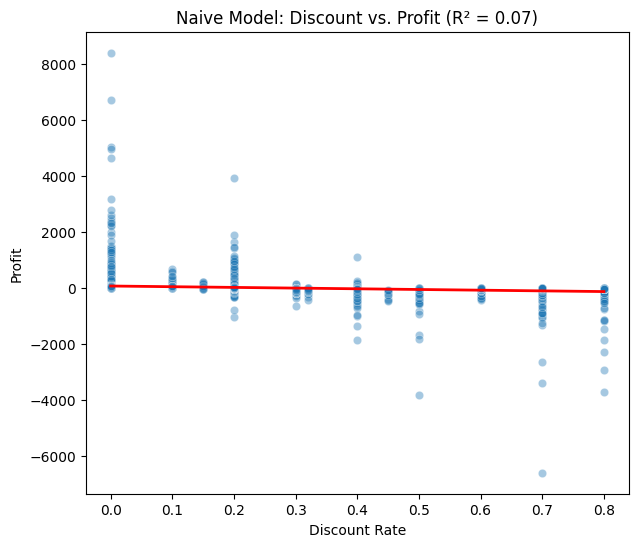

In [7]:
# Naive model: Discount vs Profit, with Model V1's regression line overlaid
plt.figure(figsize=(7,6))
sns.scatterplot(x=df['Discount'], y=df['Profit'], alpha=0.4)

x_range = np.linspace(df['Discount'].min(), df['Discount'].max(), 100)
y_line = model_v1.intercept_ + model_v1.coef_[0] * x_range
plt.plot(x_range, y_line, color='red', linewidth=2)

plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.title('Naive Model: Discount vs. Profit (R² = 0.07)')
plt.show()


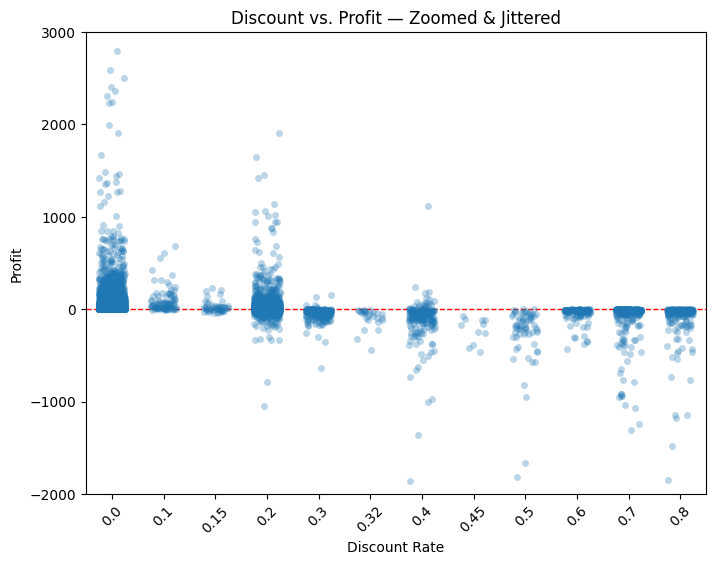

In [8]:
# Zoomed & jittered version — makes discount-tier density visible
plt.figure(figsize=(8,6))
sns.stripplot(x=df['Discount'], y=df['Profit'], alpha=0.3, jitter=0.25)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.ylim(-2000, 3000)
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.title('Discount vs. Profit — Zoomed & Jittered')
plt.xticks(rotation=45)
plt.show()


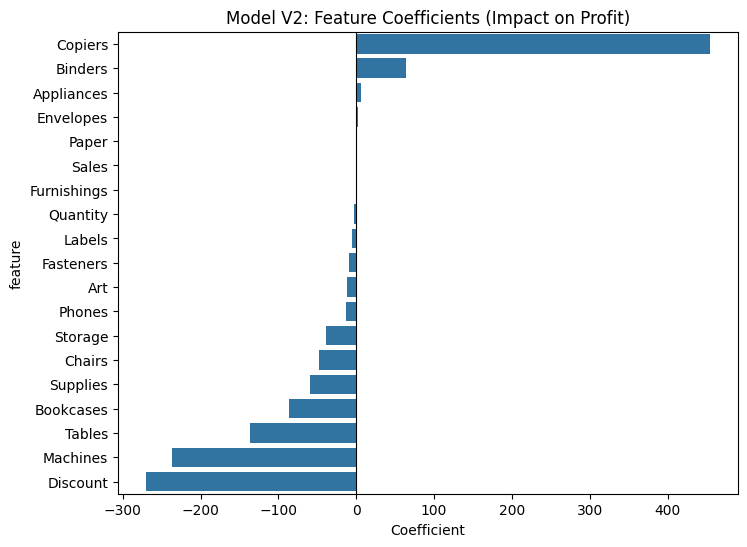

In [9]:
# Model V2 feature coefficients — what actually drives Profit
plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='feature', data=coef_df_sorted)
plt.title('Model V2: Feature Coefficients (Impact on Profit)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.show()


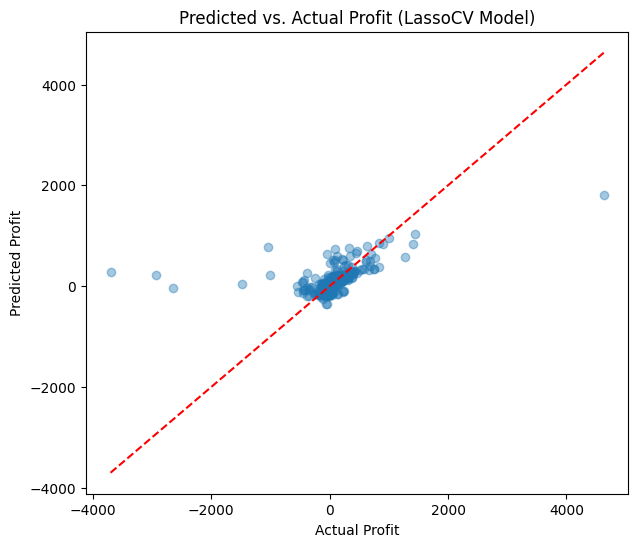

In [10]:
# Predicted vs Actual Profit — shows model performance honestly, including its limits
y_pred = lasso_cv_model.predict(X_test_scaled)

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Predicted vs. Actual Profit (LassoCV Model)')
plt.show()


## 7. Summary

- **Naive model** (Discount only): R² = 0.07 — direction correct, explanatory power weak.
- **Model V2** (+ Sales, Quantity, Sub-Category): R² = 0.25 — a 4x improvement.
- **Key finding:** Tables (flagged in early EDA as the top loss-maker) is only the 3rd-most-negative category once Discount is controlled for — it's discounted ~67% more heavily than average. The real structural drag is **Machines**; **Copiers** is an unrecognized profit driver.
- **LassoCV** (properly scaled, cross-validated) confirms the model isn't overfitting: 16 of 19 features carry genuine signal; only Envelopes, Labels, and Fasteners (all low-volume, low-profit-magnitude categories) were dropped.
- **Limitation:** even the best model explains only ~25% of profit variation. Region, Segment, and shipping cost are natural next variables to test.